Once deleted, variables cannot be recovered. Proceed (y/[n])? y
Solar.R     7
Wind        0
Temp        0
Ozone      37
dtype: int64
Solar.R     0
Wind        0
Temp        0
Ozone      37
dtype: int64


<ipython-input-49-5a5169f1db58>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Solar.R'] = df['Solar.R'].fillna(df['Solar.R'].median())


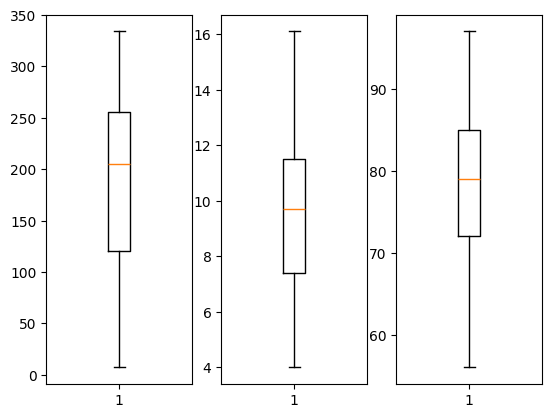

In [49]:
%reset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics  #median 모듈

# 데이터 전처리
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer  #결측치를 knn으로 대채해주는 함수

# 사용하는 모델
from sklearn import linear_model
from sklearn.neighbors import KNeighborsRegressor

# 모델 구현 모듈
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam

# 1. 데이터로딩
ozone = pd.read_csv('/content/drive/MyDrive/KDThome/ozone.csv')
df = ozone[['Solar.R','Wind','Temp','Ozone']]

# 2. 데이터전처리
# 2-1. 독립변수에 대한 결측치는 median으로 처리
print(df.isnull().sum(axis=0))
df['Solar.R'] = df['Solar.R'].fillna(df['Solar.R'].median())
print(df.isnull().sum(axis=0))

# 2-2. 독립변수에 대한 이상치는 mean으로 처리
# 이상치 확인
# z-score 이상치 기준 설정
zscore_threshold = 1.8
# 각 컬럼별 z-score 계산 및 이상치 여부 판별
wind_zscore = np.abs(stats.zscore(df['Wind'].values)) > zscore_threshold
ozone_zscore = np.abs(stats.zscore(df['Ozone'].values)) > zscore_threshold
# 이상치를 mean으로 대체
df.loc[wind_zscore, 'Wind'] = df['Wind'].mean()
df.loc[ozone_zscore, 'Ozone'] = df['Ozone'].mean()

fig = plt.figure()
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)
ax1.boxplot(df['Solar.R'])
ax2.boxplot(df['Wind'])
ax3.boxplot(df['Temp'])
plt.show()

In [50]:
# 2-4. 정규화 진행
# 학습데이터 분리
x_data = df.drop('Ozone', axis=1, inplace=False).values
t_data = df['Ozone'].values.reshape(-1,1)

# 정규화
scaler_x = MinMaxScaler()
scaler_t = MinMaxScaler()
x_data_norm = scaler_x.fit_transform(x_data)
t_data_norm = scaler_t.fit_transform(t_data)

# 2-5. 종속변수에 대한 결측치는 knn을 이용해서 예측값으로 처리
# 결측치 뽑아내기
#print(df['Ozone'].isnull().sum(axis=0))  #37
ozone_nan = df['Ozone'].isnull().values
ozone_only_nan = x_data_norm[ozone_nan]
#print(ozone_only_nan)
# KNN 모델 학습 (결측치가 없는 데이터만 사용)
knn_regression = KNeighborsRegressor(n_neighbors=2)
knn_regression.fit(x_data_norm[~ozone_nan], t_data_norm[~ozone_nan])  # NaN 제외 데이터로 학습
# 결측치가 있는 데이터 예측
predicted_values = knn_regression.predict(ozone_only_nan)
# 예측된 값 원래 스케일로 복원
predicted_values_original = scaler_t.inverse_transform(predicted_values)
# 결측치 대체
df.loc[ozone_nan, 'Ozone'] = predicted_values_original.ravel()  #1차원으로 변경해주기
print(df['Ozone'].isnull().sum()) #0
df.info()
# 다시 정규화해서 모델 학습에 사용
x_data_norm = scaler_x.transform(x_data)
t_data_norm = scaler_t.transform(t_data)

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Solar.R  153 non-null    float64
 1   Wind     153 non-null    float64
 2   Temp     153 non-null    int64  
 3   Ozone    153 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 4.9 KB


In [53]:
print("x_data_norm:", np.isnan(x_data_norm).sum())
print("t_data_norm:", np.isnan(t_data_norm).sum())
#print( predicted_values)
#print(t_data_no

x_data_norm: 0
t_data_norm: 0


In [ ]:
# 3. 모델 구현
model = Sequential()
model.add(Flatten(input_shape=(3,)))
model.add(Dense(units=1,
                activation='linear'))
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='mse')

# 4. 학습
model.fit(x_data_norm,
          t_data_norm,
          epochs=1000,
          verbose=1)



In [57]:
# 5. 결과 예측
test_data = np.array([[310, 15, 80]])
test_data_norm = scaler_x.transform(test_data)  # 정규화 추가
result_norm = model.predict(test_data_norm)
result = scaler_t.inverse_transform(result_norm)

print(result)


# 결과값은 [[38.759~~~]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[119.56498]]
